# Memory-Split PoC — Optimal (GPT-5.6-sol) Retriever

**Question.** At a fixed parameter budget, does a model that *offloads facts* to an external retriever (**SPLIT**) beat a dense twin that stores them in-weights (**DENSE**) once retrieval is perfect?

We assume an **optimal retriever** whose golden knowledge is generated by **GPT-5.6-sol** (`openai-group/gpt-5.6-sol`) via the TrueFoundry gateway. Facts are **real Wikidata triples** (PopQA), so GPT genuinely knows them. Single-hop; the two arms share one corpus, model, budget, and init — the only difference is whether fact values carry training loss.

**Scale.** Defaults to the team's primary science scale **d160m (~162M params)**. Use `--model d360m` (~356M) for the stretch scale (needs an A100 / Colab Pro).

**Runtime:** pick a **GPU** runtime (Runtime -> Change runtime type -> GPU; A100 recommended for d160m/d360m). Run cells top to bottom. You'll paste a TrueFoundry token when prompted.

**Caveats:** the held-out fact-QA gap is partly definitional (dense never saw those facts); the seen split is the fairer capacity comparison; the token budget here is far smaller than the team's cluster runs, so the reasoning composite is indicative, not final.

## 1. Get the code
The PoC lives on branch `poc/optimal-retriever` of the public fork `sidvenkatayogi/Memory-Split` — no GitHub token needed to clone.

In [1]:
import os
REPO_URL = "https://github.com/sidvenkatayogi/Memory-Split.git"
BRANCH = "poc/optimal-retriever"
if not os.path.isdir("Memory-Split") and os.path.basename(os.getcwd()) != "Memory-Split":
    !git clone --branch {BRANCH} --single-branch {REPO_URL}
if os.path.isdir("Memory-Split"):
    %cd Memory-Split
!git rev-parse --abbrev-ref HEAD

/content/Memory-Split
poc/optimal-retriever


In [2]:
# Colab preinstalls torch/numpy/matplotlib/pyyaml with a CUDA-matched build.
# Install ONLY the missing runtime deps so we never reinstall (and risk
# breaking GPU) torch. `datasets` is not needed at runtime (facts are committed).
!pip install -q tiktoken openai
import torch; print('torch', torch.__version__, '| cuda:', torch.cuda.is_available(),
                    '|', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU')

torch 2.11.0+cu128 | cuda: True | NVIDIA A100-SXM4-80GB


## 2. Persist to Google Drive (recommended for overnight runs)
Colab runtimes are ephemeral: a disconnect wipes the local disk. This cell mounts Drive and points **checkpoints + the (paid) GPT golden cache + results** at a Drive folder via `POC_PERSIST_DIR`. The corpus stays local (fast) and is rebuilt byte-identically from the same seeds, so a checkpoint resumes cleanly.

**After a disconnect:** re-run cells 1-2, then the **build** cell (fast, deterministic), then the **train** cell — it auto-resumes from the last Drive checkpoint. Skip this cell if you don't mind re-running from scratch.

In [3]:
from google.colab import drive
drive.mount('/content/drive')
import os
os.environ['POC_PERSIST_DIR'] = '/content/drive/MyDrive/memory_split_poc'
os.makedirs(os.environ['POC_PERSIST_DIR'], exist_ok=True)
print('checkpoints + golden cache + results ->', os.environ['POC_PERSIST_DIR'])

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
checkpoints + golden cache + results -> /content/drive/MyDrive/memory_split_poc


## 3. TrueFoundry credentials
Paste your TrueFoundry token (used as `OPENAI_API_KEY`; the SDK just points at the gateway). The smoke call fails fast here if the token/model is wrong — before any training time is spent.

In [ ]:
import os, getpass
os.environ["OPENAI_API_KEY"] = getpass.getpass("TrueFoundry token: ")
os.environ["OPENAI_BASE_URL"] = "https://tfy.promptlens.trilogy.com/v1"
os.environ["POC_GPT_MODEL"] = "openai-group/gpt-5.5"

import sys; sys.path.insert(0, ".")
from evals.gpt_oracle import GatewayClient
print("gateway smoke ->", GatewayClient().smoke())  # should print e.g. 'Paris'

## 4. Build the shared corpus (offline; facts are committed, stays local)

In [5]:
!python scripts/poc_run.py --stage build

[poc] stage=build device=cuda
[build] 18164 docs (realfact=14364, igsm=1500, deduction=1500, bed=800); seen=2394 heldout=606; eval factqa=50 (heldout 25 + seen 25)
[build] dense: 1139086 tokens, masked 0.000
[build] split: 1262518 tokens, masked 0.034


## 5. Train the matched twins (DENSE then SPLIT)
Same model, budget, and init; only the loss mask differs. `--model d160m` (~162M, the team's primary scale) by default; pass `--model d360m` (~356M, needs A100) for the stretch. Bump `--steps` for a longer overnight run (checkpoints every `--ckpt-minutes` to Drive; auto-resumes; add `--fresh` to restart).

In [6]:
!python scripts/poc_run.py --stage train --device auto --model d160m --steps 4000 --ckpt-minutes 5

[poc] stage=train device=cuda
[train] model=d160m checkpoints -> /content/drive/MyDrive/memory_split_poc/runs/d160m (PERSISTED (Drive))
[train] dense: 162.2M params, micro_bs=8 tokens/step=16384
[train] dense: done at step 4000 (loss_ema=0.0067)
[train] split: 162.2M params, micro_bs=8 tokens/step=16384
[train] split: done at step 4000 (loss_ema=0.0078)


## 6. Generate golden knowledge with GPT-5.6-sol (one cached call per eval item)

In [7]:
!python scripts/poc_run.py --stage gen-golden

[poc] stage=gen-golden device=cuda
[gen-golden] model=openai-group/gpt-5.6-sol for 50 items
[gen-golden] wrote 50 golden values -> /content/drive/MyDrive/memory_split_poc/golden_knowledge.jsonl (GPT fidelity vs PopQA gold = 0.500)


## 7. Evaluate + report
SPLIT @ GPT-oracle vs DENSE @ closed-book on 50 fact-QA items (seen + held-out), plus the reasoning composite and the gold-oracle upper bound.

In [8]:
!python scripts/poc_run.py --stage eval --gold-oracle --device auto
!python scripts/poc_run.py --stage report

[poc] stage=eval device=cuda
[eval] wrote /content/drive/MyDrive/memory_split_poc/poc_results.json

=== Fact-QA answer accuracy (optimal retriever) ===
condition                          all        held-out            seen
SPLIT @ GPT-oracle        48.0% (n=50)    48.0% (n=25)    48.0% (n=25)
DENSE @ closed-book       16.0% (n=50)     4.0% (n=25)    28.0% (n=25)
SPLIT @ gold (upper)     100.0% (n=50)   100.0% (n=25)   100.0% (n=25)

GPT-5.6-sol fidelity vs PopQA gold: 50.0%

=== Knowledge-free reasoning composite (supporting) ===
arm             igsm   deduction   composite
dense           2.0%       42.0%       22.0%
split           0.0%       30.0%       15.0%
[poc] stage=report device=cuda

=== Fact-QA answer accuracy (optimal retriever) ===
condition                          all        held-out            seen
SPLIT @ GPT-oracle        48.0% (n=50)    48.0% (n=25)    48.0% (n=25)
DENSE @ closed-book       16.0% (n=50)     4.0% (n=25)    28.0% (n=25)
SPLIT @ gold (upper)     100.0% 

{
  "n_eval": 50,
  "factqa": {
    "split_gpt_oracle": {
      "all": {
        "answer": 0.48,
        "answer_ci": [
          0.3479691239550571,
          0.6148848774119157
        ],
        "no_lookup_rate": 0.0,
        "n": 50
      },
      "heldout": {
        "answer": 0.48,
        "answer_ci": [
          0.30031003928960015,
          0.6650178204685269
        ],
        "no_lookup_rate": 0.0,
        "n": 25
      },
      "seen": {
        "answer": 0.48,
        "answer_ci": [
          0.30031003928960015,
          0.6650178204685269
        ],
        "no_lookup_rate": 0.0,
        "n": 25
      }
    },
    "dense_closed_book": {
      "all": {
        "answer": 0.16,
        "answer_ci": [
          0.08337321362087698,
          0.2851448096176598
        ],
        "no_lookup_rate": 1.0,
        "n": 50
      },
      "heldout": {
        "answer": 0.04,
        "answer_ci": [
          0.007096050386699165,
          0.19544472405022525
        ],
        "n

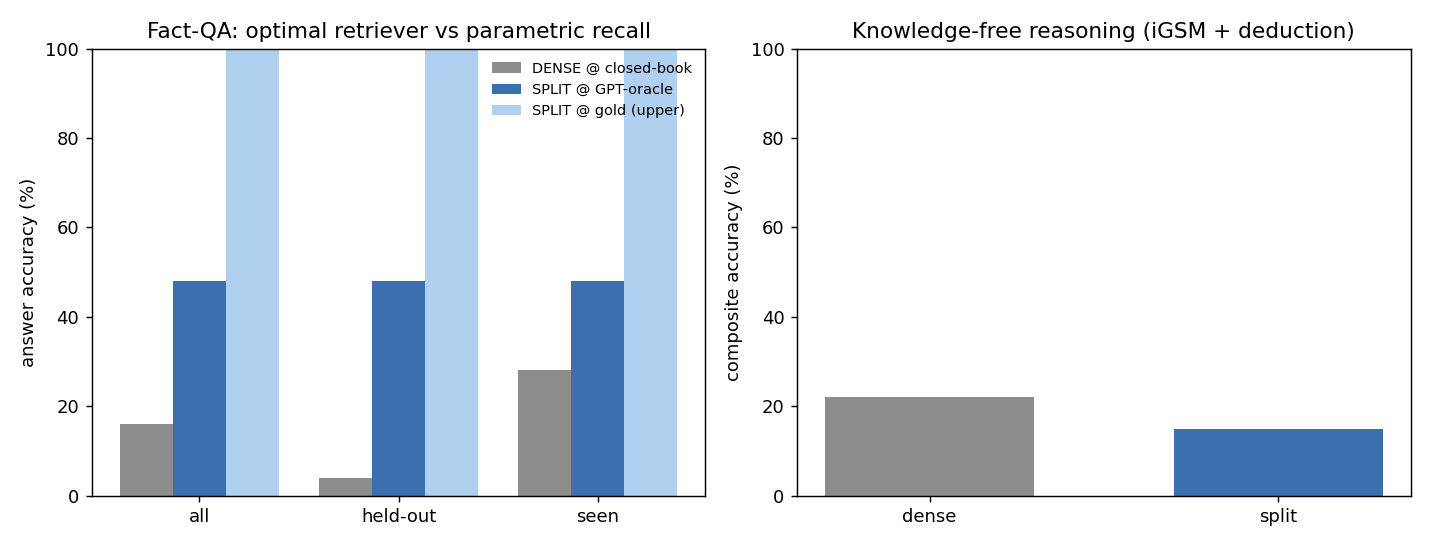

In [9]:
import json, os
from IPython.display import Image, display
persist = os.environ.get('POC_PERSIST_DIR', 'data/poc')
print(json.dumps(json.load(open(f'{persist}/poc_results.json')), indent=2))
display(Image(f'{persist}/poc_figure.png'))